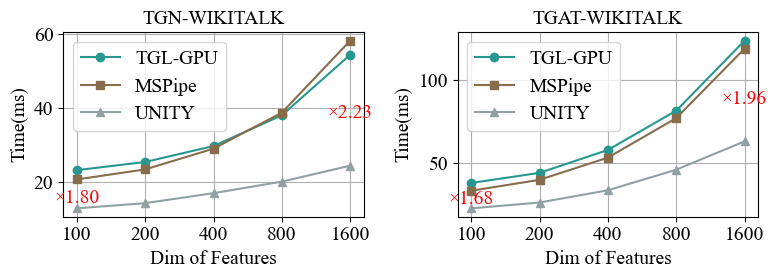

In [1]:
import yaml
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'Times New Roman'
plt.rc('font', size=14)
plt.rc('axes', titlesize=14)
# 读取dim_feat.yaml文件
with open('dim_feat.yaml', 'r') as file:
    data = yaml.load(file, Loader=yaml.FullLoader)

# 提取数据
wikitalk_tgn_tgl = data['WIKITALK']['TGN']['TGL']
wikitalk_tgn_mspipe = data['WIKITALK']['TGN']['MSPipe']
wikitalk_tgn_unity = data['WIKITALK']['TGN']['UNITY']
wikitalk_tgat_tgl = data['WIKITALK']['TGAT']['TGL']
wikitalk_tgat_mspipe = data['WIKITALK']['TGAT']['MSPipe']
wikitalk_tgat_unity = data['WIKITALK']['TGAT']['UNITY']

# X轴标签
dimensions = ['100', '200', '400', '800', '1600']

# 数据
tgn_tgl = list(wikitalk_tgn_tgl.values())
tgn_mspipe = list(wikitalk_tgn_mspipe.values())
tgn_unity = list(wikitalk_tgn_unity.values())
tgat_tgl = list(wikitalk_tgat_tgl.values())
tgat_mspipe = list(wikitalk_tgat_mspipe.values())
tgat_unity = list(wikitalk_tgat_unity.values())

# 计算倍数差
def get_multiplicative_diff(data, unity_data):
    return [d / unity_data[i] for i, d in enumerate(data)]

# 计算TGN和TGAT的倍数差
tgn_tgl_diff = get_multiplicative_diff(tgn_tgl, tgn_unity)
tgn_mspipe_diff = get_multiplicative_diff(tgn_mspipe, tgn_unity)
tgn_unity_diff = [1] * len(tgn_unity)  # UNITY与自己相差的倍数为1
tgat_tgl_diff = get_multiplicative_diff(tgat_tgl, tgat_unity)
tgat_mspipe_diff = get_multiplicative_diff(tgat_mspipe, tgat_unity)
tgat_unity_diff = [1] * len(tgat_unity)  # UNITY与自己相差的倍数为1

# 创建两个子图
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

# 绘制TGN模型的子图
axes[0].plot(dimensions, tgn_tgl, label='TGL-GPU', marker='o', color='#289790')
axes[0].plot(dimensions, tgn_mspipe, label='MSPipe', marker='s', color='#876d4c')
axes[0].plot(dimensions, tgn_unity, label='UNITY', marker='^', color='#91a1a3')

# 在TGN子图的D100和D1600位置添加倍数差
for i in [0, 4]:  # D100是索引0，D1600是索引4
    sorted_vals = sorted(zip(dimensions, tgn_tgl_diff), key=lambda x: x[1], reverse=True)
    second_highest = sorted_vals[1]
    # 找到D100和D1600的第二高点并标注
    if i == 0:
        axes[0].text(dimensions[i], tgn_tgl[i]-10, 
                     f'×{tgn_tgl_diff[i]:.2f}', 
                     ha='center', va='bottom', color='red')
    elif i == 4:
        axes[0].text(dimensions[i], tgn_tgl[i]-18, 
                     f'×{tgn_tgl_diff[i]:.2f}', 
                     ha='center', va='bottom', color='red')

# 设置TGN图的标题和标签
axes[0].set_title('TGN-WIKITALK')
axes[0].set_xlabel('Dim of Features')
axes[0].set_ylabel('Time(ms)')
axes[0].grid(True)
axes[0].legend()

# 绘制TGAT模型的子图
axes[1].plot(dimensions, tgat_tgl, label='TGL-GPU', marker='o', color='#289790')
axes[1].plot(dimensions, tgat_mspipe, label='MSPipe', marker='s', color='#876d4c')
axes[1].plot(dimensions, tgat_unity, label='UNITY', marker='^', color='#91a1a3')

# 在TGAT子图的D100和D1600位置添加倍数差
for i in [0, 4]:  # D100是索引0，D1600是索引4
    sorted_vals = sorted(zip(dimensions, tgat_tgl_diff), key=lambda x: x[1], reverse=True)
    second_highest = sorted_vals[1]
    # 找到D100和D1600的第二高点并标注
    if i == 0:
        axes[1].text(dimensions[i], tgat_tgl[i]-15, 
                     f'×{tgat_tgl_diff[i]:.2f}', 
                     ha='center', va='bottom', color='red')
    elif i == 4:
        axes[1].text(dimensions[i], (tgat_tgl[i]+tgat_unity[i])/2-10, 
                     f'×{tgat_tgl_diff[i]:.2f}', 
                     ha='center', va='bottom', color='red')

# 设置TGAT图的标题和标签
axes[1].set_title('TGAT-WIKITALK')
axes[1].set_xlabel('Dim of Features')
axes[1].set_ylabel('Time(ms)')
axes[1].grid(True)
axes[1].legend()

# 调整布局
plt.tight_layout()
plt.savefig('exp4.pdf', bbox_inches='tight')
plt.show()
